# Estimating Delay-Discounting Parameters

This notebook reverses the simulation process from Notebook 2.

Instead of supplying a discount rate k and predicting choices, I observe a
participant's choices and estimate the value of k that best explains those choices.

The workflow is:

1. Simulate choices from a participant with a known discount rate.
2. Hide the true discount rate.
3. Test many candidate k values.
4. Calculate how likely the observed choices are under each candidate.
5. Select the k value with the highest likelihood.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
true_k = 0.02
beta = 0.5

In [3]:
def subjective_value(amount, delay, k):
    value = amount / (1 + k * delay)
    return value

def delayed_choice_probability(immediate_amount, delayed_amount, delay, k, beta):
    immediate_value = subjective_value(immediate_amount, 0, k)
    delayed_value = subjective_value(delayed_amount, delay, k)
    value_difference = delayed_value - immediate_value

    probability_delayed = 1 / (1 + np.exp(-beta * value_difference))

    return probability_delayed

def choose_reward_probabilistic(
    immediate_amount,
    delayed_amount,
    delay,
    k,
    beta
):
    p_delayed = delayed_choice_probability(
        immediate_amount,
        delayed_amount,
        delay,
        k,
        beta
    )

    random_draw = np.random.random()

    if random_draw < p_delayed:
        return "Delayed"
    else:
        return "Immediate"

In [5]:
choices = [
    {"immediate": 20, "delayed": 25, "delay": 7},
    {"immediate": 20, "delayed": 30, "delay": 30},
    {"immediate": 25, "delayed": 40, "delay": 60},
    {"immediate": 30, "delayed": 50, "delay": 90},
    {"immediate": 40, "delayed": 70, "delay": 90},
    {"immediate": 45, "delayed": 60, "delay": 180},
    {"immediate": 50, "delayed": 75, "delay": 180},
    {"immediate": 50, "delayed": 100, "delay": 365},
    {"immediate": 60, "delayed": 100, "delay": 180},
    {"immediate": 70, "delayed": 100, "delay": 365},
]

np.random.seed(42)

observations = []

for choice in choices:
    for trial in range(20):
        response = choose_reward_probabilistic(
            choice["immediate"],
            choice["delayed"],
            choice["delay"],
            true_k,
            beta
        )

        observations.append({
            "immediate": choice["immediate"],
            "delayed": choice["delayed"],
            "delay": choice["delay"],
            "choice": response
        })

df = pd.DataFrame(observations)
df

,immediate,delayed,delay,choice
0,20,25,7,Delayed
1,20,25,7,Immediate
2,20,25,7,Immediate
3,20,25,7,Delayed
4,20,25,7,Delayed
...,...,...,...,...
195,70,100,365,Immediate
196,70,100,365,Immediate
197,70,100,365,Immediate
198,70,100,365,Immediate


In [ ]:
def log_likelihood(k, beta, df):
    total = 0
    for _, row in df.iterrows():
        p_delayed = delayed_choice_probability(
            row["immediate"],
            row["delayed"],
            row["delay"],
            k,
            beta
        )
        p_delayed = np.clip(p_delayed, 1e-10, 1 - 1e-10)

        choice = row["choice"]
        if choice == "Delayed":
            total += np.log(p_delayed)
        else:
            total += np.log(1 - p_delayed)
    
    return total

In [7]:
candidate_k_values = [0.001, 0.02, 0.1]

for candidate_k in candidate_k_values:
    ll = log_likelihood(candidate_k, beta, df)
    print(candidate_k, ll)

0.001 -1308.4378611713623
0.02 -25.56286282760381
0.1 -91.11505635673149


In [11]:
candidate_ks = np.linspace(0.001, 0.1, 200)

log_likelihoods = []

for candidate_k in candidate_ks:
    ll = log_likelihood(candidate_k, beta, df)
    log_likelihoods.append(ll)

best_index = np.argmax(log_likelihoods)

estimated_k = candidate_ks[best_index]

print("True k:", true_k)
print("Estimated k:", estimated_k)

True k: 0.02
Estimated k: 0.019904522613065325


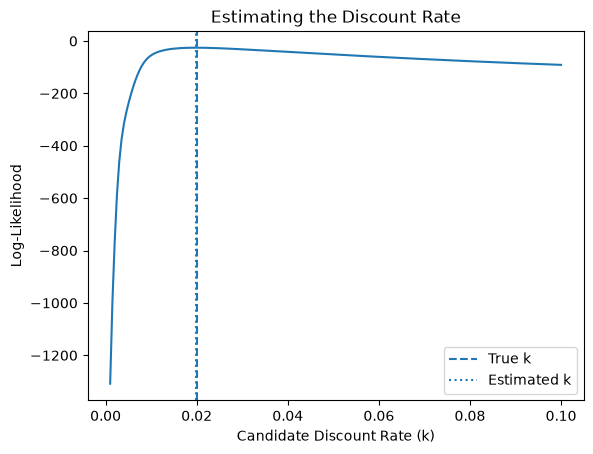

In [12]:
plt.plot(candidate_ks, log_likelihoods)

plt.axvline(true_k, linestyle="--", label="True k")
plt.axvline(estimated_k, linestyle=":", label="Estimated k")

plt.xlabel("Candidate Discount Rate (k)")
plt.ylabel("Log-Likelihood")
plt.title("Estimating the Discount Rate")
plt.legend()

plt.show()

Parameter recovery: The maximum-likelihood estimate of k was approximately 0.0199, closely recovering the simulated participant's true value of 0.0200. The close agreement provides a validation check that the estimation procedure can recover the latent discount parameter under the assumptions of the simulated model.